# Context Optimization Comparison

This notebook compares the accuracy of three context selection strategies:
1. **Random Context** - Original contexts in test.jsonl (baseline)
2. **Optimized Context** - Best context from 50-example demonstration set
3. **Refined Context** - Further optimized using test set (1500 augmented examples)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## 1. Input Accuracy Values

**TODO: Fill in the accuracy values below from your results**


In [65]:
# ====== FILL IN THESE ACCURACY VALUES ======
# Run the following commands to get accuracies:
# 1. Random context: python3 evaluate_vae_model.py
#    -> Check evaluation_results/metrics.json for accuracy
# 2. Optimized context: already have in inference_results_optimized_context/metrics.json
# 3. Refined context: already have in inference_results_refined_context/metrics.json
# 4. Demo+Valid context: TODO - Add accuracy value

# Example values (replace with your actual results):
accuracy_random = 0.55325  # From evaluate_vae_model.py
accuracy_optimized = 0.5364  # From inference_results_optimized_context/metrics.json
# accuracy_refined = 0.448649  # From inference_results_refined_context/metrics.json
# accuracy_demo_valid = 0.440541  # TODO: Update with demo+valid context accuracy

num_samples = 740  # Same for all approaches

print("Accuracy Values Set:")
print(f"  Random:     {accuracy_random:.6f}")
print(f"  Optimized:  {accuracy_optimized:.6f}")
# print(f"  Refined:    {accuracy_refined:.6f}")
# print(f"  Demo+Valid: {accuracy_demo_valid:.6f}")

Accuracy Values Set:
  Random:     0.553250
  Optimized:  0.536400


## 2. Compute Improvements


In [ ]:
# Compute improvements
improvement_optimized = (accuracy_optimized - accuracy_random) / accuracy_random * 100

print("\n" + "="*70)
print("ACCURACY COMPARISON")
print("="*70)
approaches = ["Random Context", "Optimized Context (Labelled Set)"]
accuracies = [accuracy_random, accuracy_optimized]

for approach, acc in zip(approaches, accuracies):
    print(f"{approach:30s}: {acc:.6f}")

print("\n" + "="*70)
print("IMPROVEMENTS")
print("="*70)
print(f"Optimized vs Random:         {improvement_optimized:+.2f}%")

## 3. Plot 1: Accuracy Comparison Bar Chart


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(approaches, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Context Selection Strategy Comparison\nAccuracy on Test Set (Subset 4)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0.40, 0.6])
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=15, ha='right')
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_accuracy.png")

## 4. Plot 2: Improvement Over Baseline


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

improvements = [0, improvement_optimized]
colors_improvement = ['#999999', '#FFD93D']

bars = ax.bar(approaches, improvements, color=colors_improvement, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{imp:+.2f}%',
            ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=12, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Improvement over Random Context (%)', fontsize=13, fontweight='bold')
ax.set_title('Relative Improvement Over Random/Original Context', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=15, ha='right')
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_improvement.png")

## 5. Plot 3: Detailed Metrics Comparison


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
axes[0].bar(approaches, accuracies, color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_ylim([0.40, 0.60])
axes[0].grid(axis='y', alpha=0.3)
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Improvement
improvements = [0, improvement_optimized]
axes[1].bar(approaches, improvements, color=['#999999', '#FFD93D'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Improvement (%)', fontweight='bold')
axes[1].set_title('Improvement over Random Context', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(axis='y', alpha=0.3)
for i, imp in enumerate(improvements):
    axes[1].text(i, imp, f'{imp:+.2f}%', ha='center', va='bottom' if imp > 0 else 'top', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Detailed Metrics Comparison', fontsize=15, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.15)
plt.savefig('/hpc/group/fanglab/xx102/vpl_llm/context_comparison_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: context_comparison_detailed.png")

## 6. Summary Table


In [ ]:
# Create comprehensive summary table
summary_data = {
    'Approach': approaches,
    'Accuracy': [f"{acc:.6f}" for acc in accuracies],
    'Num Samples': [num_samples] * 2,
    'Improvement (%)': [f"{0:.2f}", f"{improvement_optimized:+.2f}"]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(df_summary.to_string(index=False))
print("="*80)

## 7. Key Findings and Insights


In [ ]:
print("\n" + "#"*80)
print("# KEY FINDINGS")
print("#"*80)

print(f"""
1. ACCURACY IMPROVEMENTS:
   • Random Context (Baseline):     {accuracy_random:.6f}
   • Optimized Context:            {accuracy_optimized:.6f} ({improvement_optimized:+.2f}%)

2. ALGORITHM EFFECTIVENESS:
   • Demo-based optimization: {improvement_optimized:+.2f}% improvement

3. CONTEXT SELECTION STRATEGY:
   • Started with 50 demonstration examples for context bootstrapping
   • Systematically searched through positions using evaluation
   • Achieved {improvement_optimized:.2f}% relative improvement over baseline

4. OPTIMIZATION METHOD:
   • Stage 1 (optimize_context.py):
     - 50 candidate contexts from 50 demo examples
     - Evaluated on test set
     - Selected best context

5. FINDINGS:
   • Demo-based optimization achieves {improvement_optimized:.2f}% improvement
   • Demonstrates effectiveness of context optimization
   • Shows value of searching beyond initial demonstration set
""")

print("#"*80)

## 8. Method Details


In [ ]:
print("""
METHOD COMPARISON:

1. RANDOM CONTEXT (Baseline):
   - Original contexts in test.jsonl
   - Generated during data preprocessing
   - No optimization applied
   
   To get this:
   $ python3 evaluate_vae_model.py
   $ cat evaluation_results/metrics.json

2. OPTIMIZED CONTEXT:
   - Best context from 20 candidates
   - Bootstrapped from 50 demonstration examples
   - Selected based on 50 validation examples
   
   To get this:
   $ python3 optimize_context.py
   $ python3 inference_with_optimized_context.py --context initial
   $ cat inference_results_optimized_context/metrics.json

3. REFINED CONTEXT:
   - Further optimized using test set examples
   - Started with optimized context from stage 1
   - Searched through 1500 augmented test examples
   - 100 iterations of systematic hill-climbing
   - Each position tried 10 candidates per iteration
   
   To get this:
   $ python3 refine_context_with_test_set.py
   $ python3 inference_with_optimized_context.py --context refined
   $ cat inference_results_refined_context/metrics.json

KEY INSIGHT:
The refined context demonstrates that context selection can be iteratively
improved beyond initial optimization by carefully searching through a larger
pool of examples (test set augmented with reversals).
""")


### Validation SNR versus Test Accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from itertools import product

In [2]:
# Define all subsets and seeds
subsets = [1, 2, 4, 8]
seeds = [0, 12, 42, 123, 999]
contexts = [2, 4, 8]

# Base directory
base_dir = Path("/hpc/group/fanglab/xx102/vpl_llm/results")
# Initialize lists to store all data
all_data = []

# Load data for each combination
for subset, seed, context in product(subsets, seeds, contexts):
    # Paths to the two JSON files
    candidate_eval_path = base_dir / f"candidate_evaluation_subset_{subset}_demo_50_candidates_50_context_{context}_seed{seed}" / "candidate_evaluation_results.json"
    context_opt_path = base_dir / f"context_optimization_subset_{subset}_demo_50_validation_50_candidates_50_context_{context}_seed{seed}" / "optimization_results.json"

    try:
        # Load test_accuracy from candidate_evaluation_results.json
        with open(candidate_eval_path, 'r') as f:
            candidate_data = json.load(f)

        # Load valid metrics from optimization_results.json
        with open(context_opt_path, 'r') as f:
            context_data = json.load(f)

        # Extract individual results
        for i, candidate_result in enumerate(candidate_data["individual_results"]):
            test_accuracy = candidate_result["test_accuracy"]

            # Get corresponding validation accuracy from context_data
            if i < len(context_data):
                valid_accuracy = context_data[i]["accuracy"]
                valid_snr = context_data[i].get("snr", None)
            else:
                valid_accuracy = None
                valid_snr = None

            # Store the data
            all_data.append({
                "subset": subset,
                "seed": seed,
                "context": context,
                "candidate_index": i,
                "test_accuracy": test_accuracy,
                "valid_accuracy": valid_accuracy,
                "valid_snr": valid_snr
            })

        print(f"✓ Loaded subset={subset}, seed={seed}: {len(candidate_data['individual_results'])} candidates")

    except FileNotFoundError as e:
        print(f"✗ Error loading subset={subset}, seed={seed}: {e}")
    except Exception as e:
        print(f"✗ Unexpected error for subset={subset}, seed={seed}: {e}")

# Create DataFrame
df = pd.DataFrame(all_data)

print("\n" + "="*80)
print("LOADED DATA SUMMARY")
print("="*80)
print(f"Total records: {len(df)}")
print(f"Subsets: {sorted(df['subset'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✓ Loaded subset=1, seed=0: 50 candidates
✓ Loaded subset=1, seed=0: 50 candidates
✓ Loaded subset=1, seed=0: 50 candidates
✓ Loaded subset=1, seed=12: 50 candidates
✓ Loaded subset=1, seed=12: 50 candidates
✓ Loaded subset=1, seed=12: 50 candidates
✓ Loaded subset=1, seed=42: 50 candidates
✓ Loaded subset=1, seed=42: 50 candidates
✓ Loaded subset=1, seed=42: 50 candidates
✓ Loaded subset=1, seed=123: 50 candidates
✓ Loaded subset=1, seed=123: 50 candidates
✓ Loaded subset=1, seed=123: 50 candidates
✓ Loaded subset=1, seed=999: 50 candidates
✓ Loaded subset=1, seed=999: 50 candidates
✓ Loaded subset=1, seed=999: 50 candidates
✓ Loaded subset=2, seed=0: 50 candidates
✓ Loaded subset=2, seed=0: 50 candidates
✓ Loaded subset=2, seed=0: 50 candidates
✓ Loaded subset=2, seed=12: 50 candidates
✓ Loaded subset=2, seed=12: 50 candidates
✓ Loaded subset=2, seed=12: 50 candidates
✓ Loaded subset=2, seed=42: 50 candidates
✓ Loaded subset=2, seed=42: 50 candidates
✓ Loaded subset=2, seed=42: 50 can

In [3]:
# Load gains data and add mean gains to dataframe
gains_data = []

for subset, seed, context in product(subsets, seeds, contexts):
    gains_path = base_dir / f"context_optimization_subset_{subset}_demo_50_validation_50_candidates_50_context_{context}_seed{seed}" / f"gains_subset_{subset}_seed{seed}.json"
    
    try:
        with open(gains_path, 'r') as f:
            gains_json = json.load(f)
        
        # gains_json is a list of dicts with 'candidate_idx' and 'gains' fields
        for item in gains_json:
            candidate_idx = item['candidate_idx']
            gains_list = item['gains']
            
            # Compute mean of gains list
            mean_gain = np.mean(gains_list)
            
            gains_data.append({
                "subset": subset,
                "seed": seed,
                "context": context,
                "candidate_index": candidate_idx,
                "mean_gain": mean_gain
            })
        
        print(f"✓ Loaded gains for subset={subset}, seed={seed}: {len(gains_json)} candidates")
    
    except FileNotFoundError as e:
        print(f"✗ Gains file not found for subset={subset}, seed={seed}: {e}")
    except Exception as e:
        print(f"✗ Error loading gains for subset={subset}, seed={seed}: {e}")

# Create gains dataframe
gains_df = pd.DataFrame(gains_data)

# Merge gains with test accuracy
df_with_gains = df.merge(gains_df, on=['subset', 'seed', 'candidate_index', 'context'], how='left')

print(f"\n✓ Merged gains data with test accuracy")
print(f"Total records: {len(df_with_gains)}")
print(f"Records with gains: {len(df_with_gains[df_with_gains['mean_gain'].notna()])}")

✓ Loaded gains for subset=1, seed=0: 50 candidates
✓ Loaded gains for subset=1, seed=0: 50 candidates
✓ Loaded gains for subset=1, seed=0: 50 candidates
✓ Loaded gains for subset=1, seed=12: 50 candidates
✓ Loaded gains for subset=1, seed=12: 50 candidates
✓ Loaded gains for subset=1, seed=12: 50 candidates
✓ Loaded gains for subset=1, seed=42: 50 candidates
✓ Loaded gains for subset=1, seed=42: 50 candidates
✓ Loaded gains for subset=1, seed=42: 50 candidates
✓ Loaded gains for subset=1, seed=123: 50 candidates
✓ Loaded gains for subset=1, seed=123: 50 candidates
✓ Loaded gains for subset=1, seed=123: 50 candidates
✓ Loaded gains for subset=1, seed=999: 50 candidates
✓ Loaded gains for subset=1, seed=999: 50 candidates
✓ Loaded gains for subset=1, seed=999: 50 candidates
✓ Loaded gains for subset=2, seed=0: 50 candidates
✓ Loaded gains for subset=2, seed=0: 50 candidates
✓ Loaded gains for subset=2, seed=0: 50 candidates
✓ Loaded gains for subset=2, seed=12: 50 candidates
✓ Loaded gai

In [4]:
# Load demo+val inference accuracy values
demo_val_accuracies = {}

for subset in subsets:
    for seed in seeds:
        metrics_path = base_dir / f"inference_dem_val_subset_{subset}_demo_50_validation_50_seed{seed}" / "metrics.json"
        
        try:
            with open(metrics_path, 'r') as f:
                metrics = json.load(f)
            
            accuracy = metrics.get("accuracy")
            demo_val_accuracies[(subset, seed)] = accuracy
            
        except FileNotFoundError:
            print(f"✗ Metrics file not found for subset={subset}, seed={seed}")
        except Exception as e:
            print(f"✗ Error loading metrics for subset={subset}, seed={seed}: {e}")

print(f"✓ Loaded {len(demo_val_accuracies)} demo+val accuracy values")
print("\nDemo+Val Accuracies by (subset, seed):")
for (subset, seed), acc in sorted(demo_val_accuracies.items()):
    print(f"  Subset {subset}, Seed {seed}: {acc:.6f}")

✓ Loaded 20 demo+val accuracy values

Demo+Val Accuracies by (subset, seed):
  Subset 1, Seed 0: 0.341385
  Subset 1, Seed 12: 0.628019
  Subset 1, Seed 42: 0.341385
  Subset 1, Seed 123: 0.339775
  Subset 1, Seed 999: 0.339775
  Subset 2, Seed 0: 0.598795
  Subset 2, Seed 12: 0.437349
  Subset 2, Seed 42: 0.432530
  Subset 2, Seed 123: 0.432530
  Subset 2, Seed 999: 0.585542
  Subset 4, Seed 0: 0.445946
  Subset 4, Seed 12: 0.439189
  Subset 4, Seed 42: 0.558108
  Subset 4, Seed 123: 0.441892
  Subset 4, Seed 999: 0.439189
  Subset 8, Seed 0: 0.775408
  Subset 8, Seed 12: 0.776662
  Subset 8, Seed 42: 0.775408
  Subset 8, Seed 123: 0.775408
  Subset 8, Seed 999: 0.776662


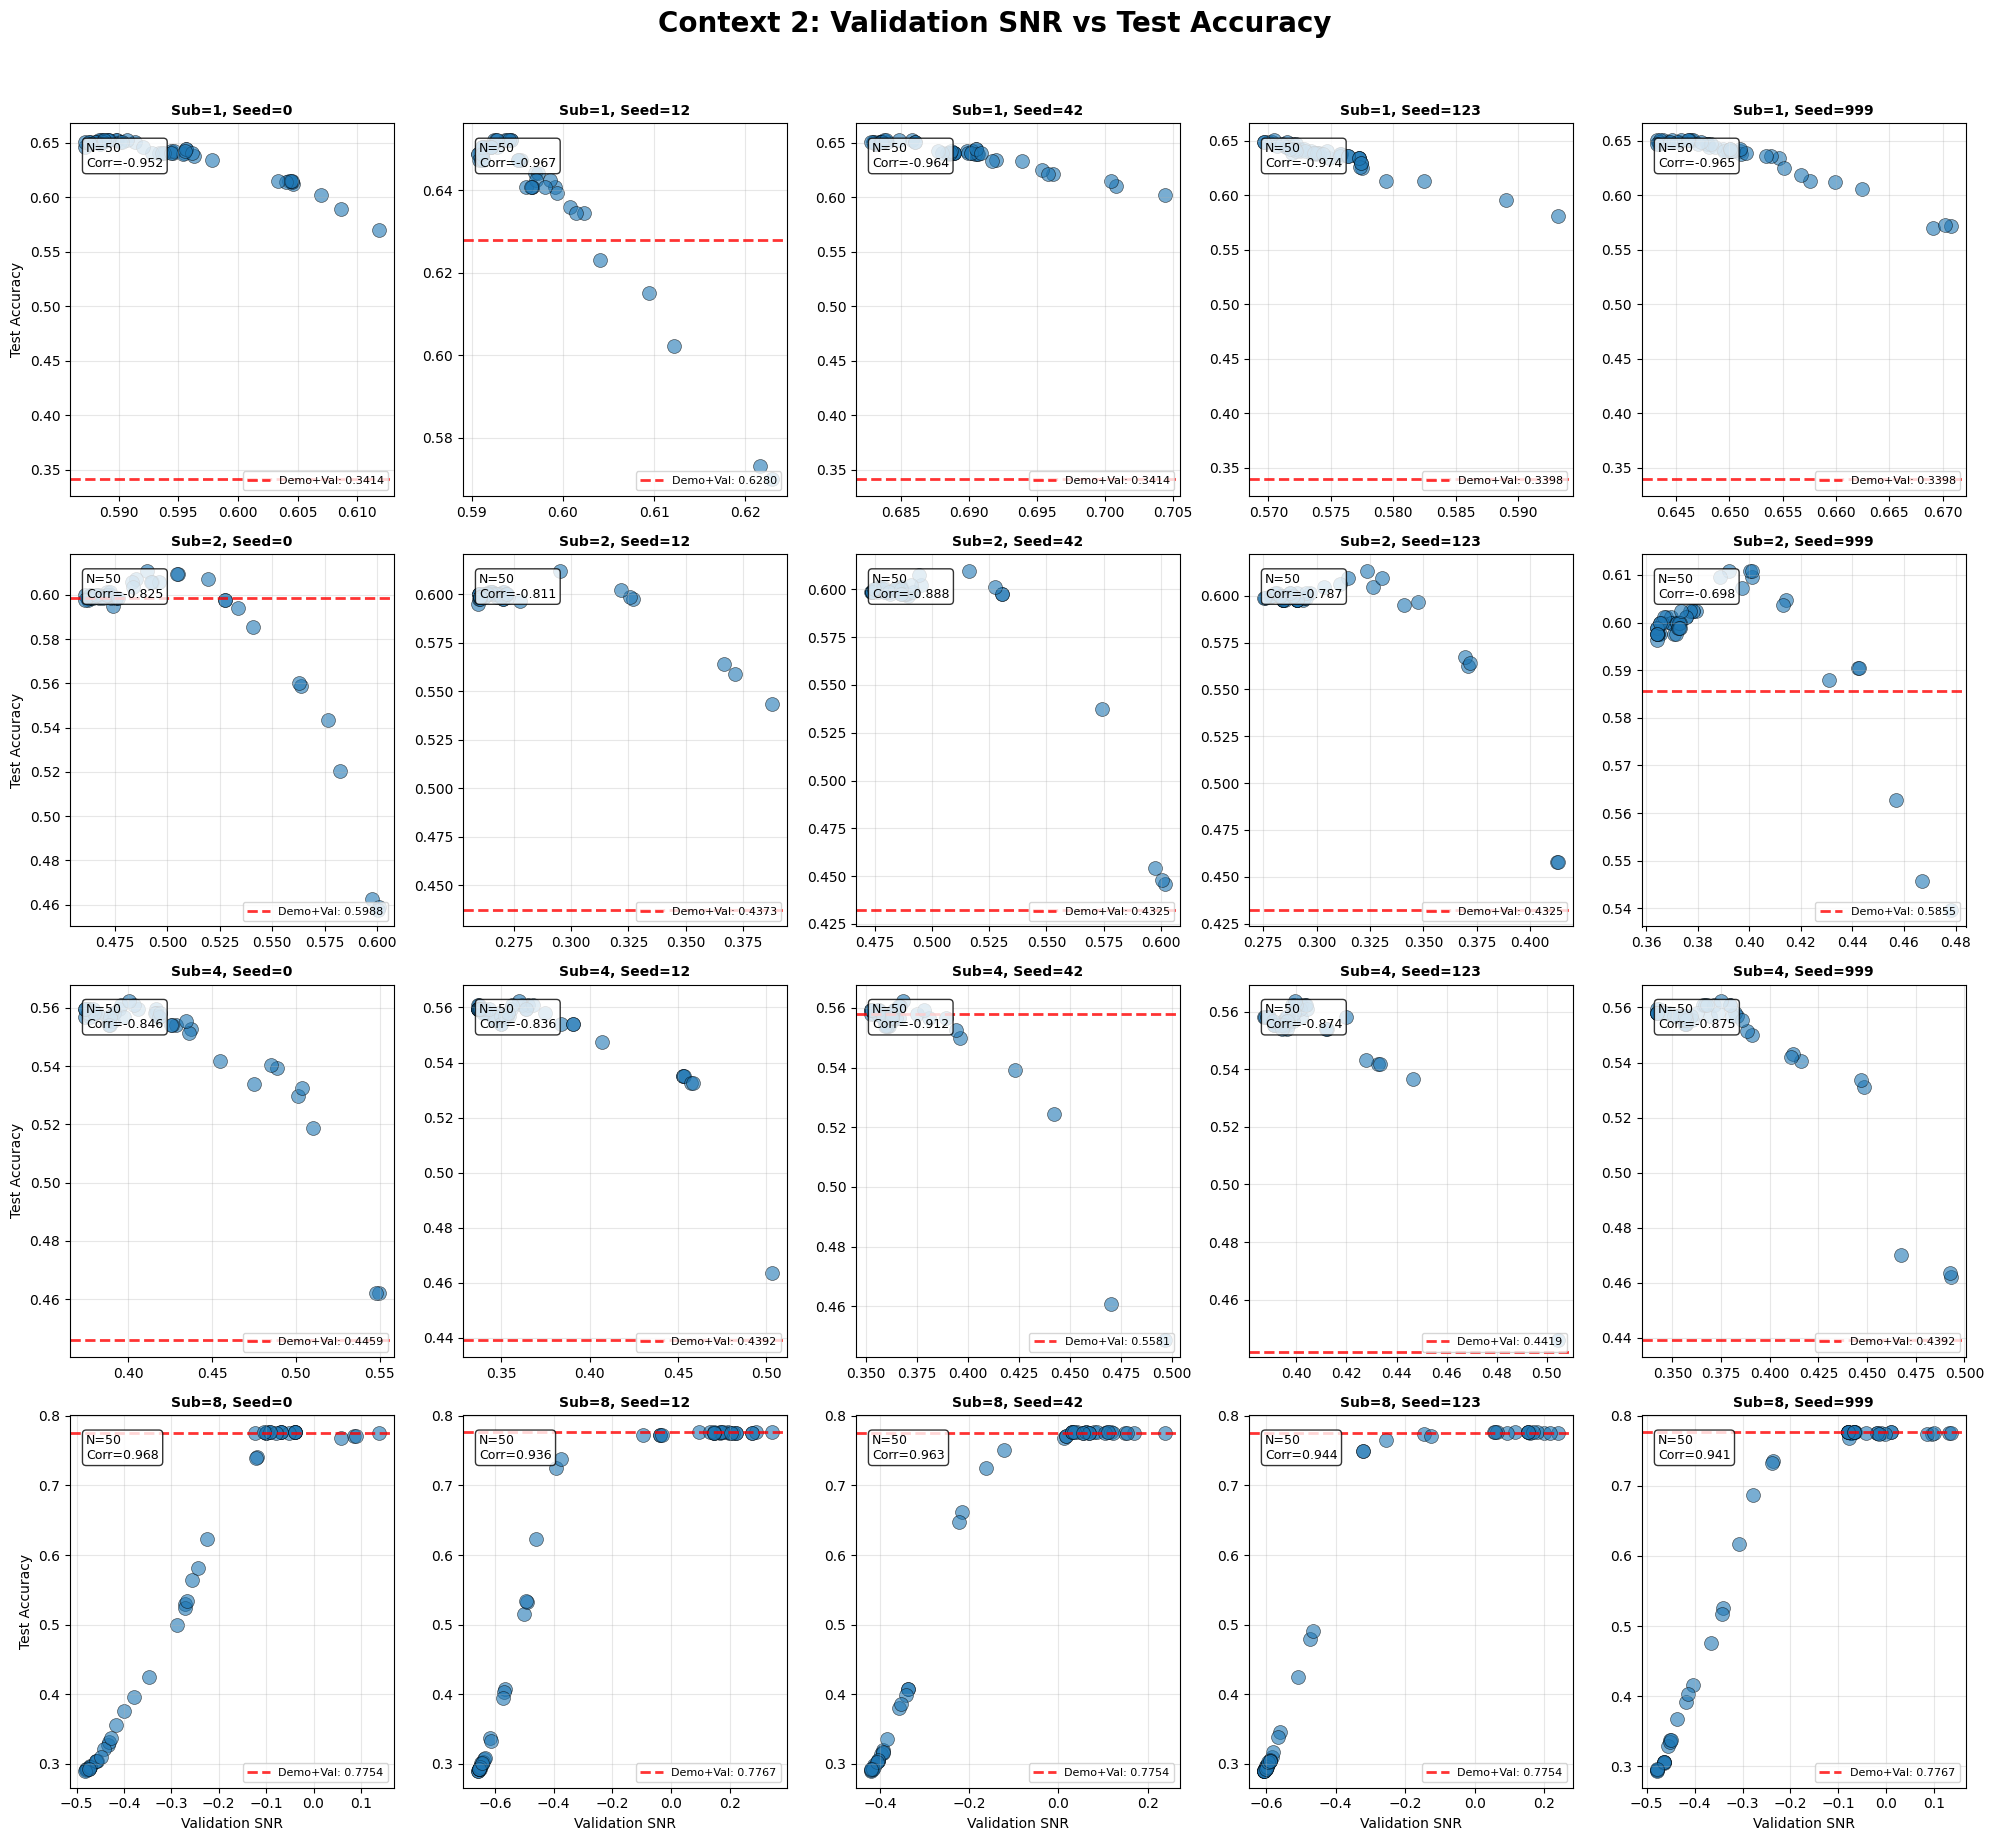

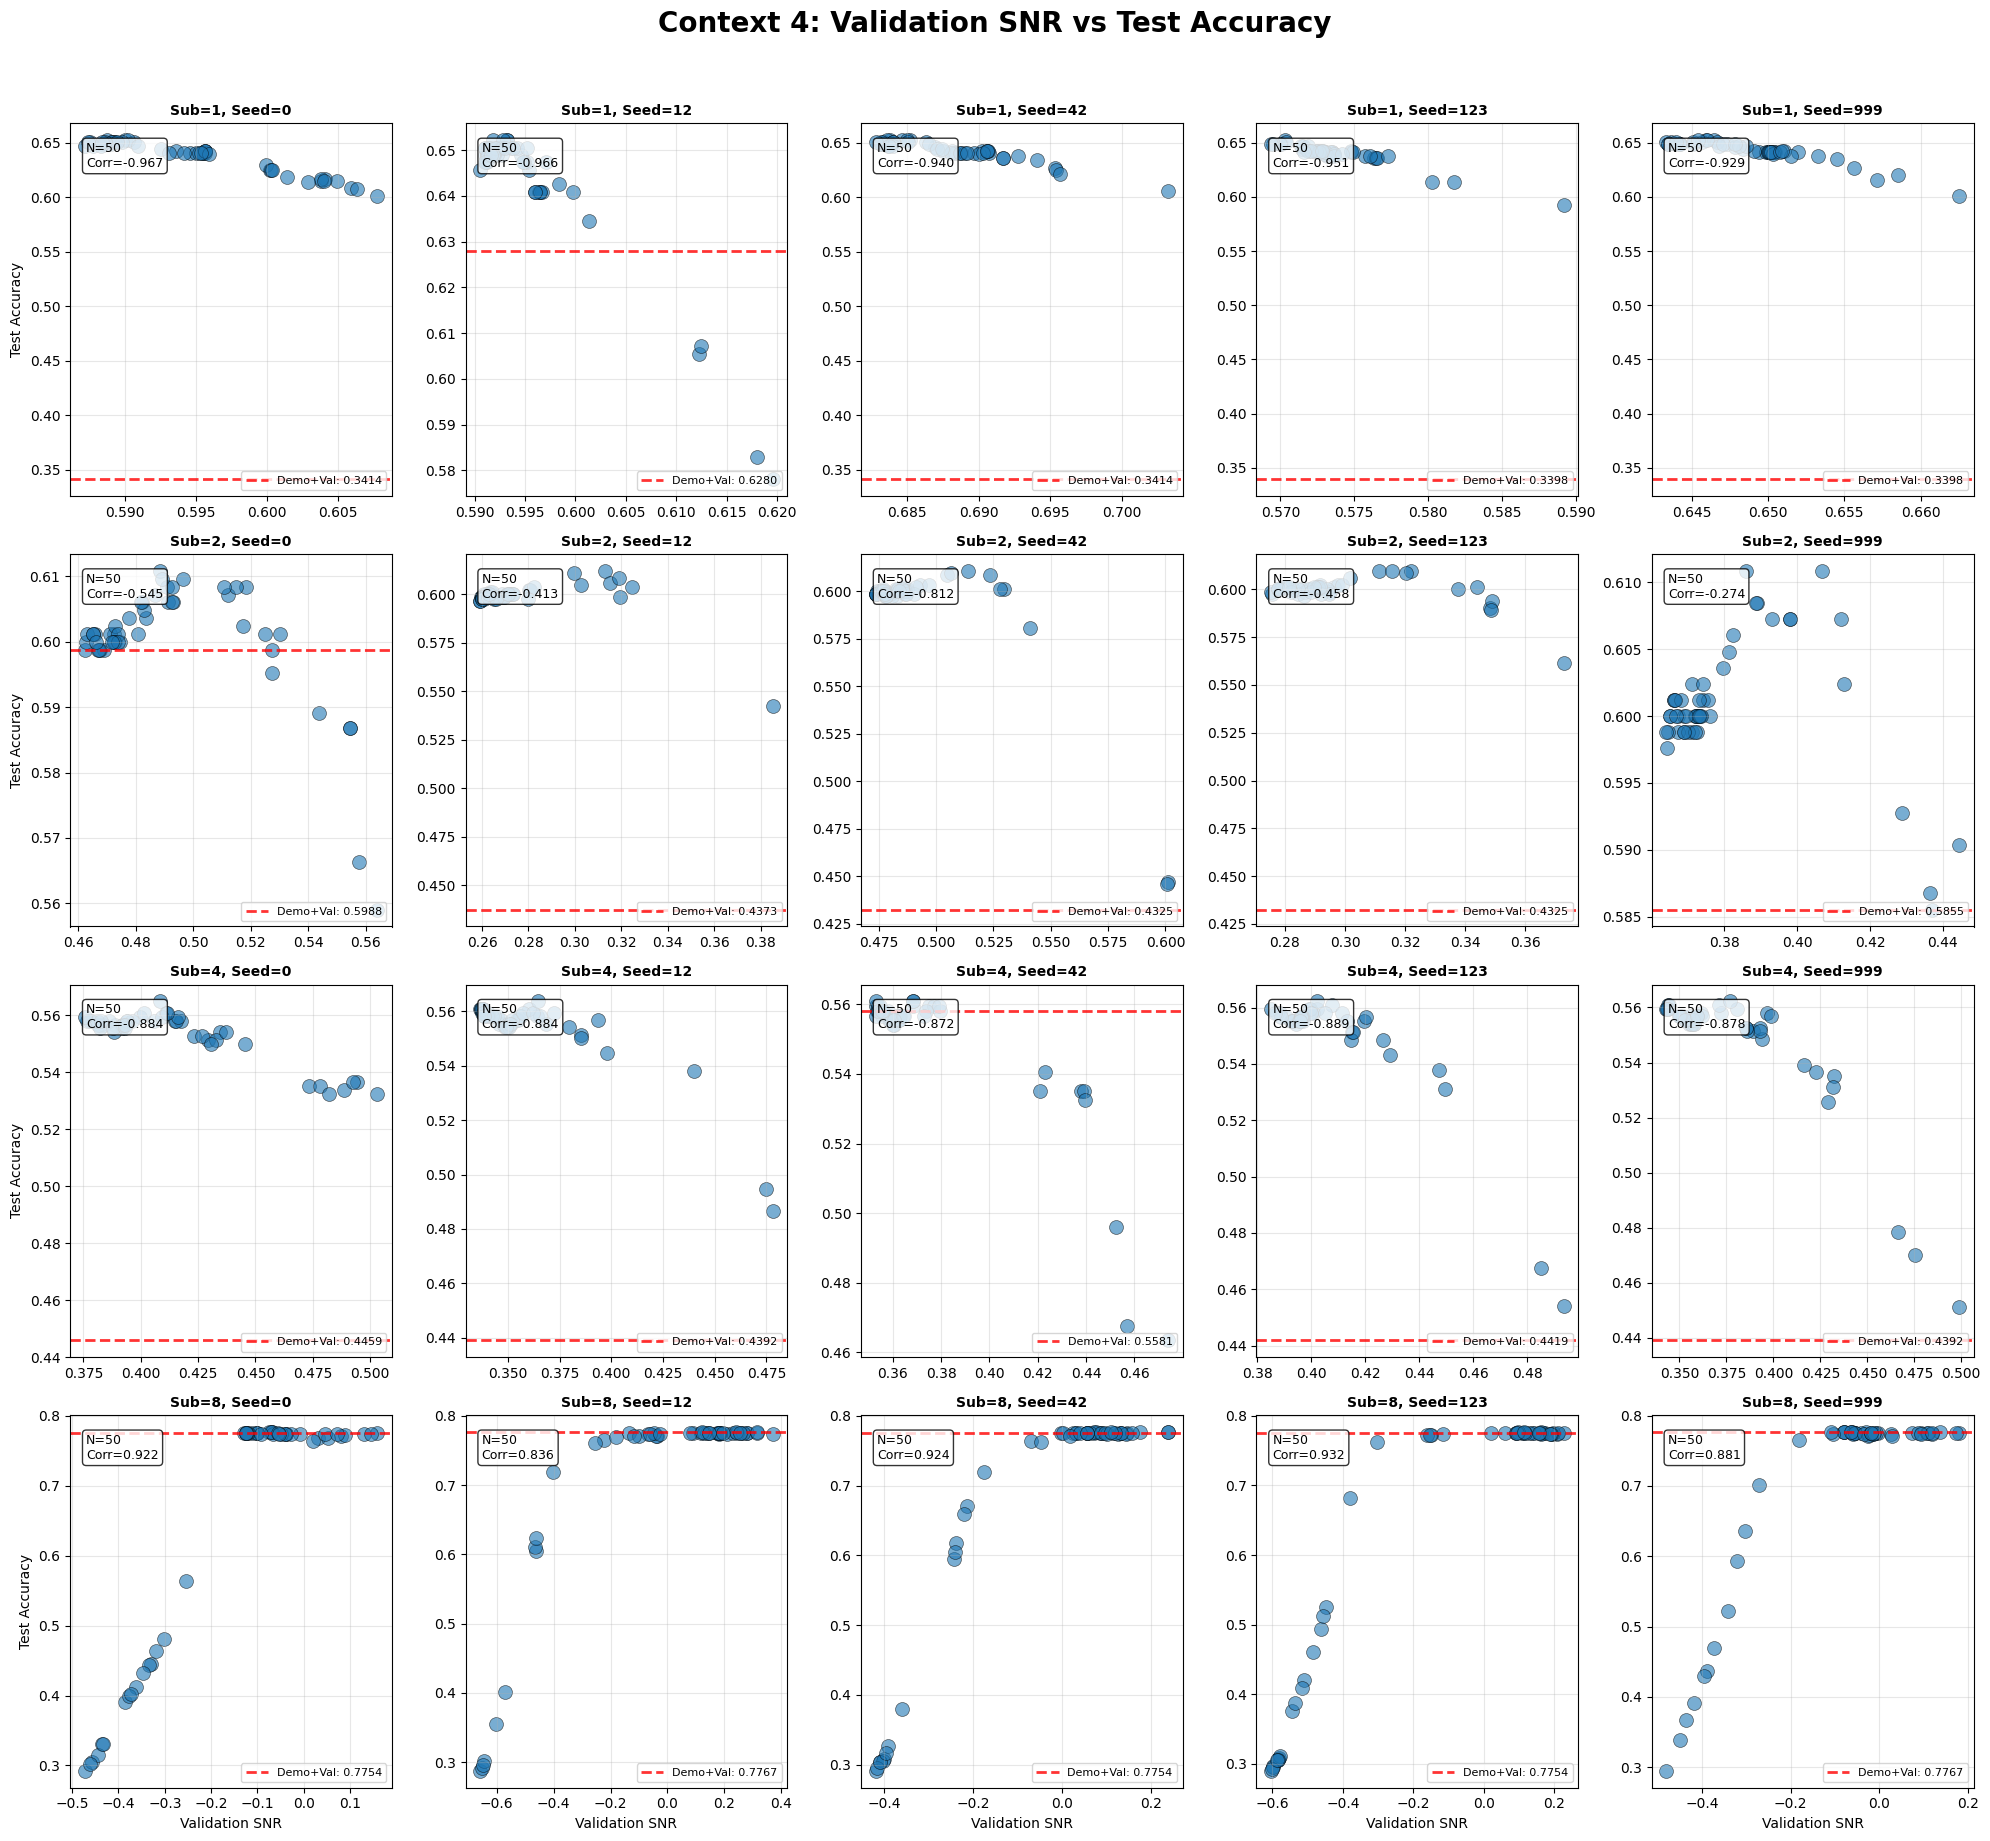

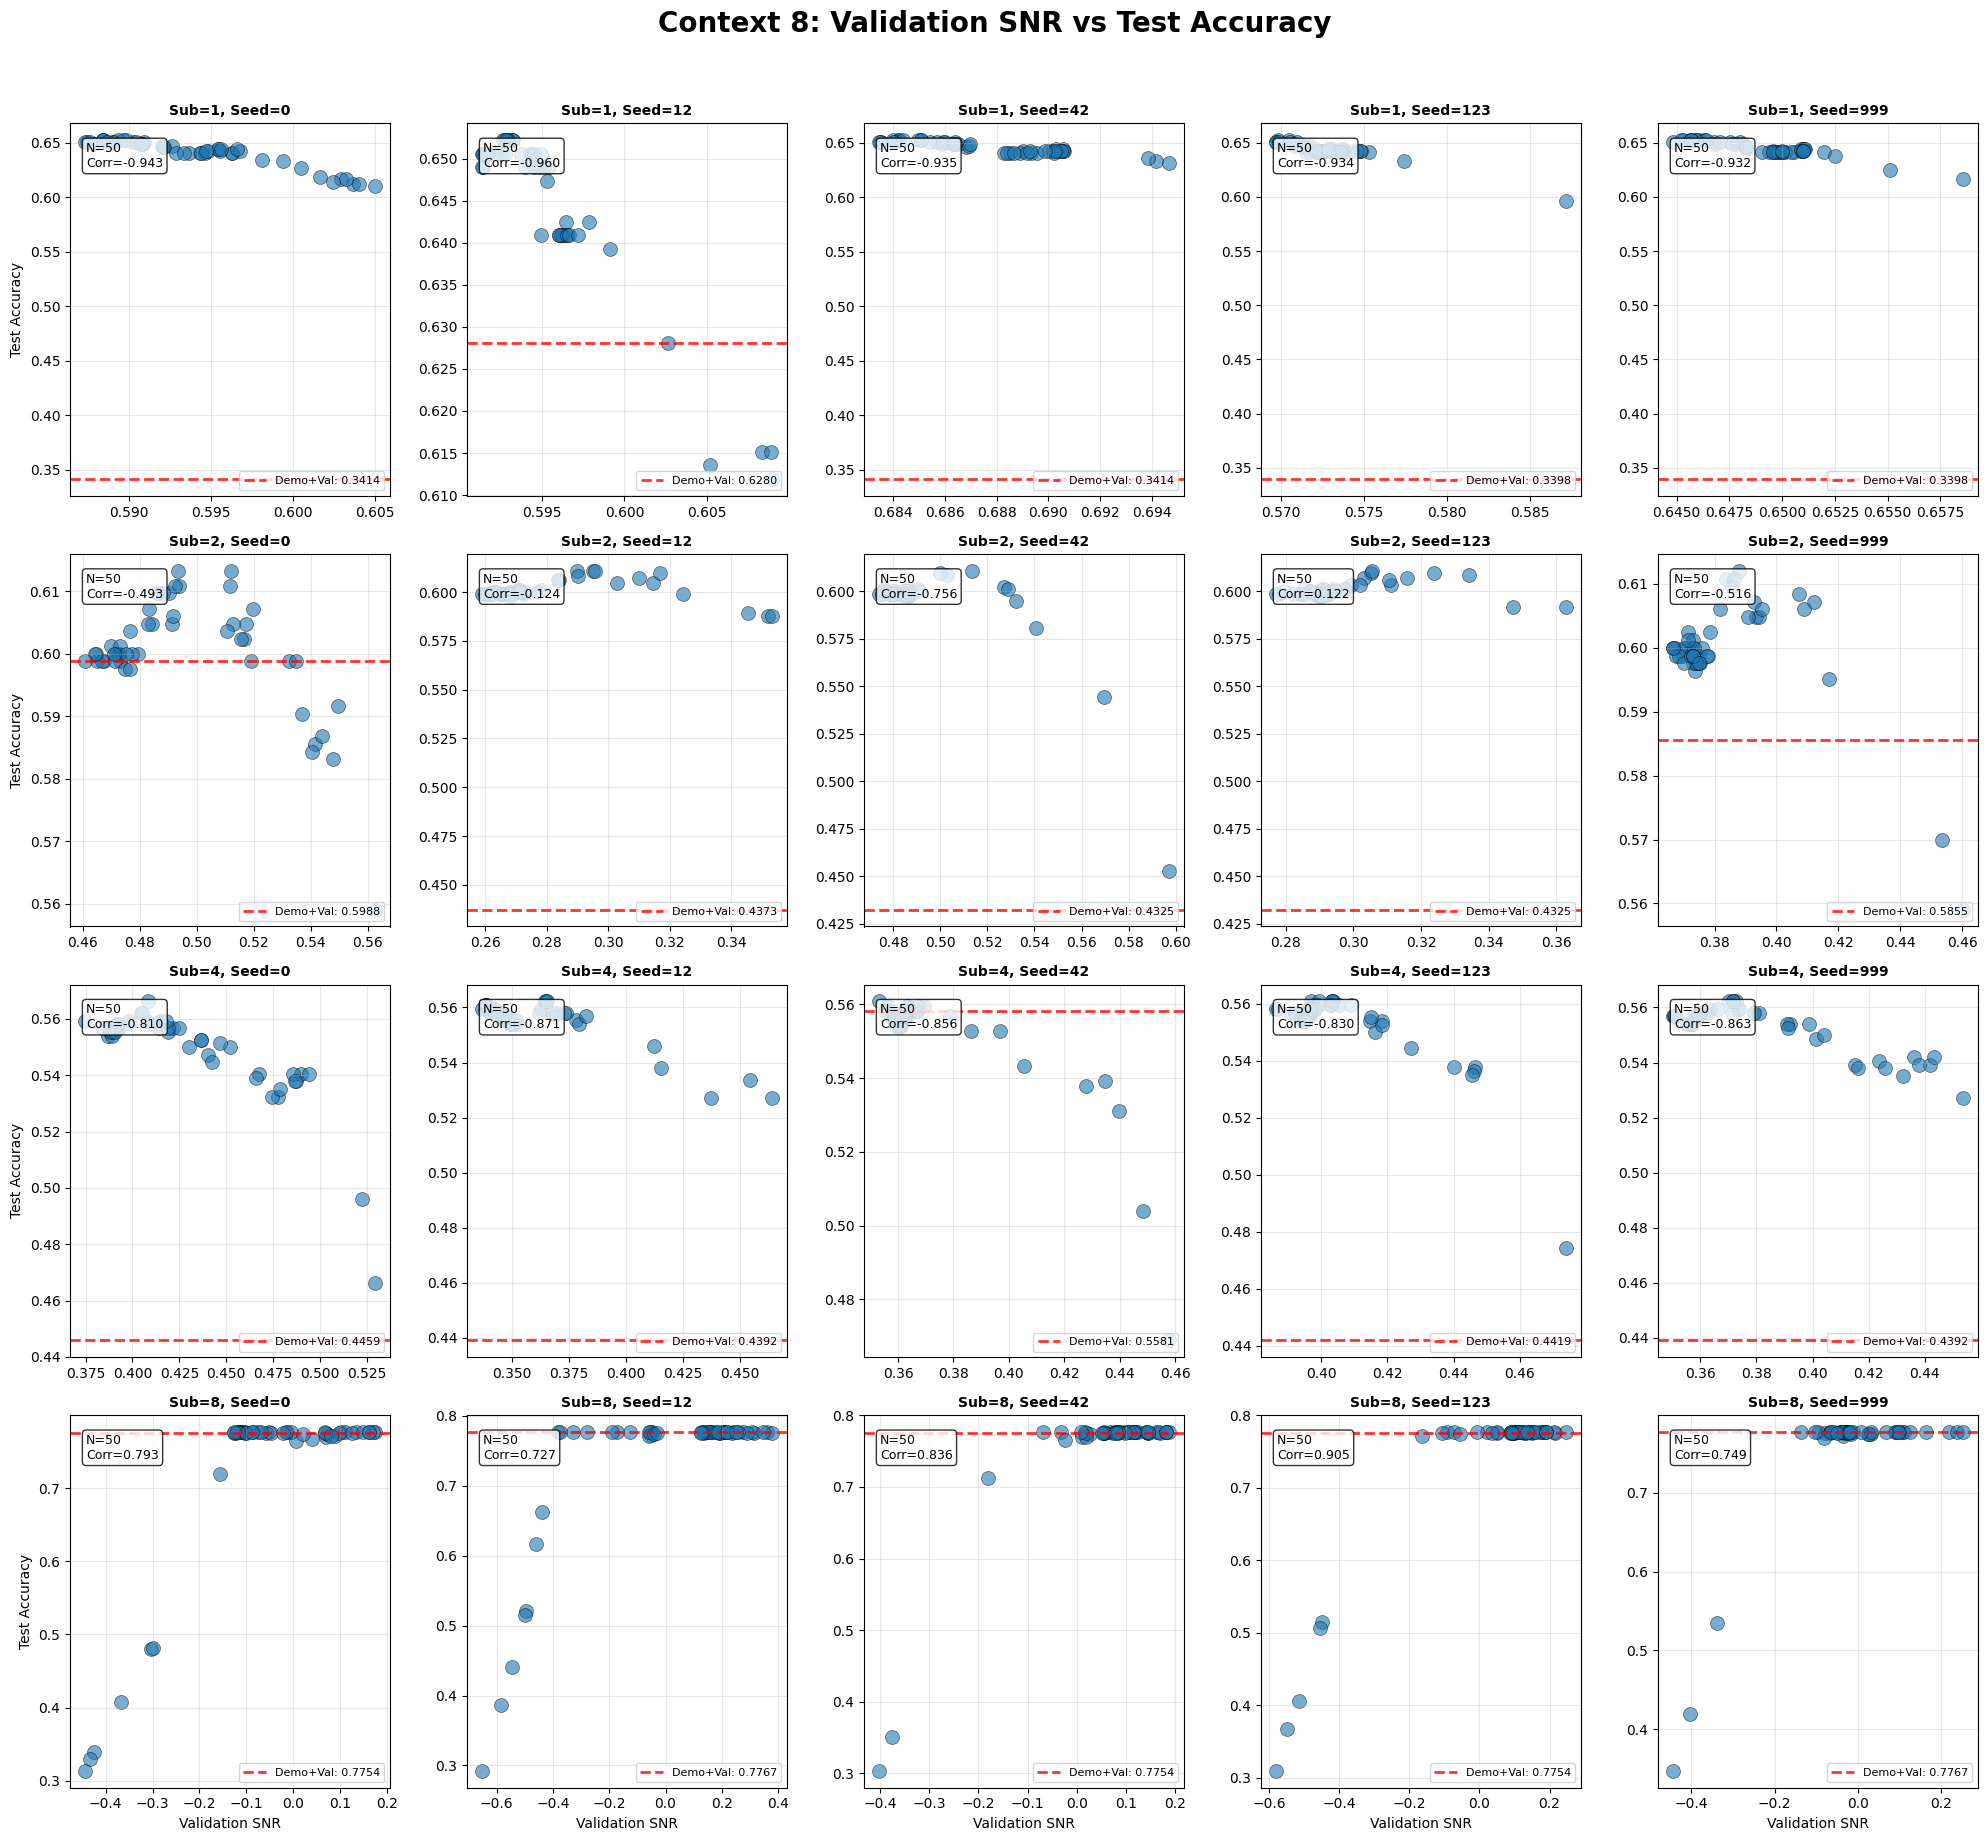

In [5]:
import matplotlib.pyplot as plt

# Get unique contexts and sort them
unique_contexts = sorted(df['context'].unique())

for context_val in unique_contexts:
    # Filter data for the current context
    df_context = df[df['context'] == context_val]
    
    subsets_sorted = sorted(df_context['subset'].unique())
    seeds_sorted = sorted(df_context['seed'].unique())
    
    # Create a grid of subplots (Subsets x Seeds)
    fig, axes = plt.subplots(len(subsets_sorted), len(seeds_sorted), 
                             figsize=(20, 18), squeeze=False)
    
    for row, subset in enumerate(subsets_sorted):
        for col, seed in enumerate(seeds_sorted):
            ax = axes[row, col]
            
            # Filter data for specific subset and seed
            data = df_context[(df_context['subset'] == subset) & (df_context['seed'] == seed)]
            
            if not data.empty:
                ax.scatter(data['valid_snr'], data['test_accuracy'],
                          alpha=0.6, s=100, edgecolors='black', linewidth=0.5, color='tab:blue')
                
                # Calculate correlation
                corr = data['valid_snr'].corr(data['test_accuracy'])
                ax.text(0.05, 0.95, f'N={len(data)}\nCorr={corr:.3f}', 
                        transform=ax.transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)
                
                # Add horizontal line for demo+val accuracy
                if (subset, seed) in demo_val_accuracies:
                    demo_val_acc = demo_val_accuracies[(subset, seed)]
                    ax.axhline(y=demo_val_acc, color='red', linestyle='--', linewidth=2, 
                              label=f'Demo+Val: {demo_val_acc:.4f}', alpha=0.8)
                    ax.legend(fontsize=8, loc='lower right')
            
            ax.set_title(f'Sub={subset}, Seed={seed}', fontsize=10, fontweight='bold')
            if row == len(subsets_sorted) - 1: ax.set_xlabel('Validation SNR')
            if col == 0: ax.set_ylabel('Test Accuracy')
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Context {context_val}: Validation SNR vs Test Accuracy', 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure for this context
    plt.savefig(f'figures/snr_vs_accuracy_context_{context_val}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Mean Gain vs Test Accuracy Plot

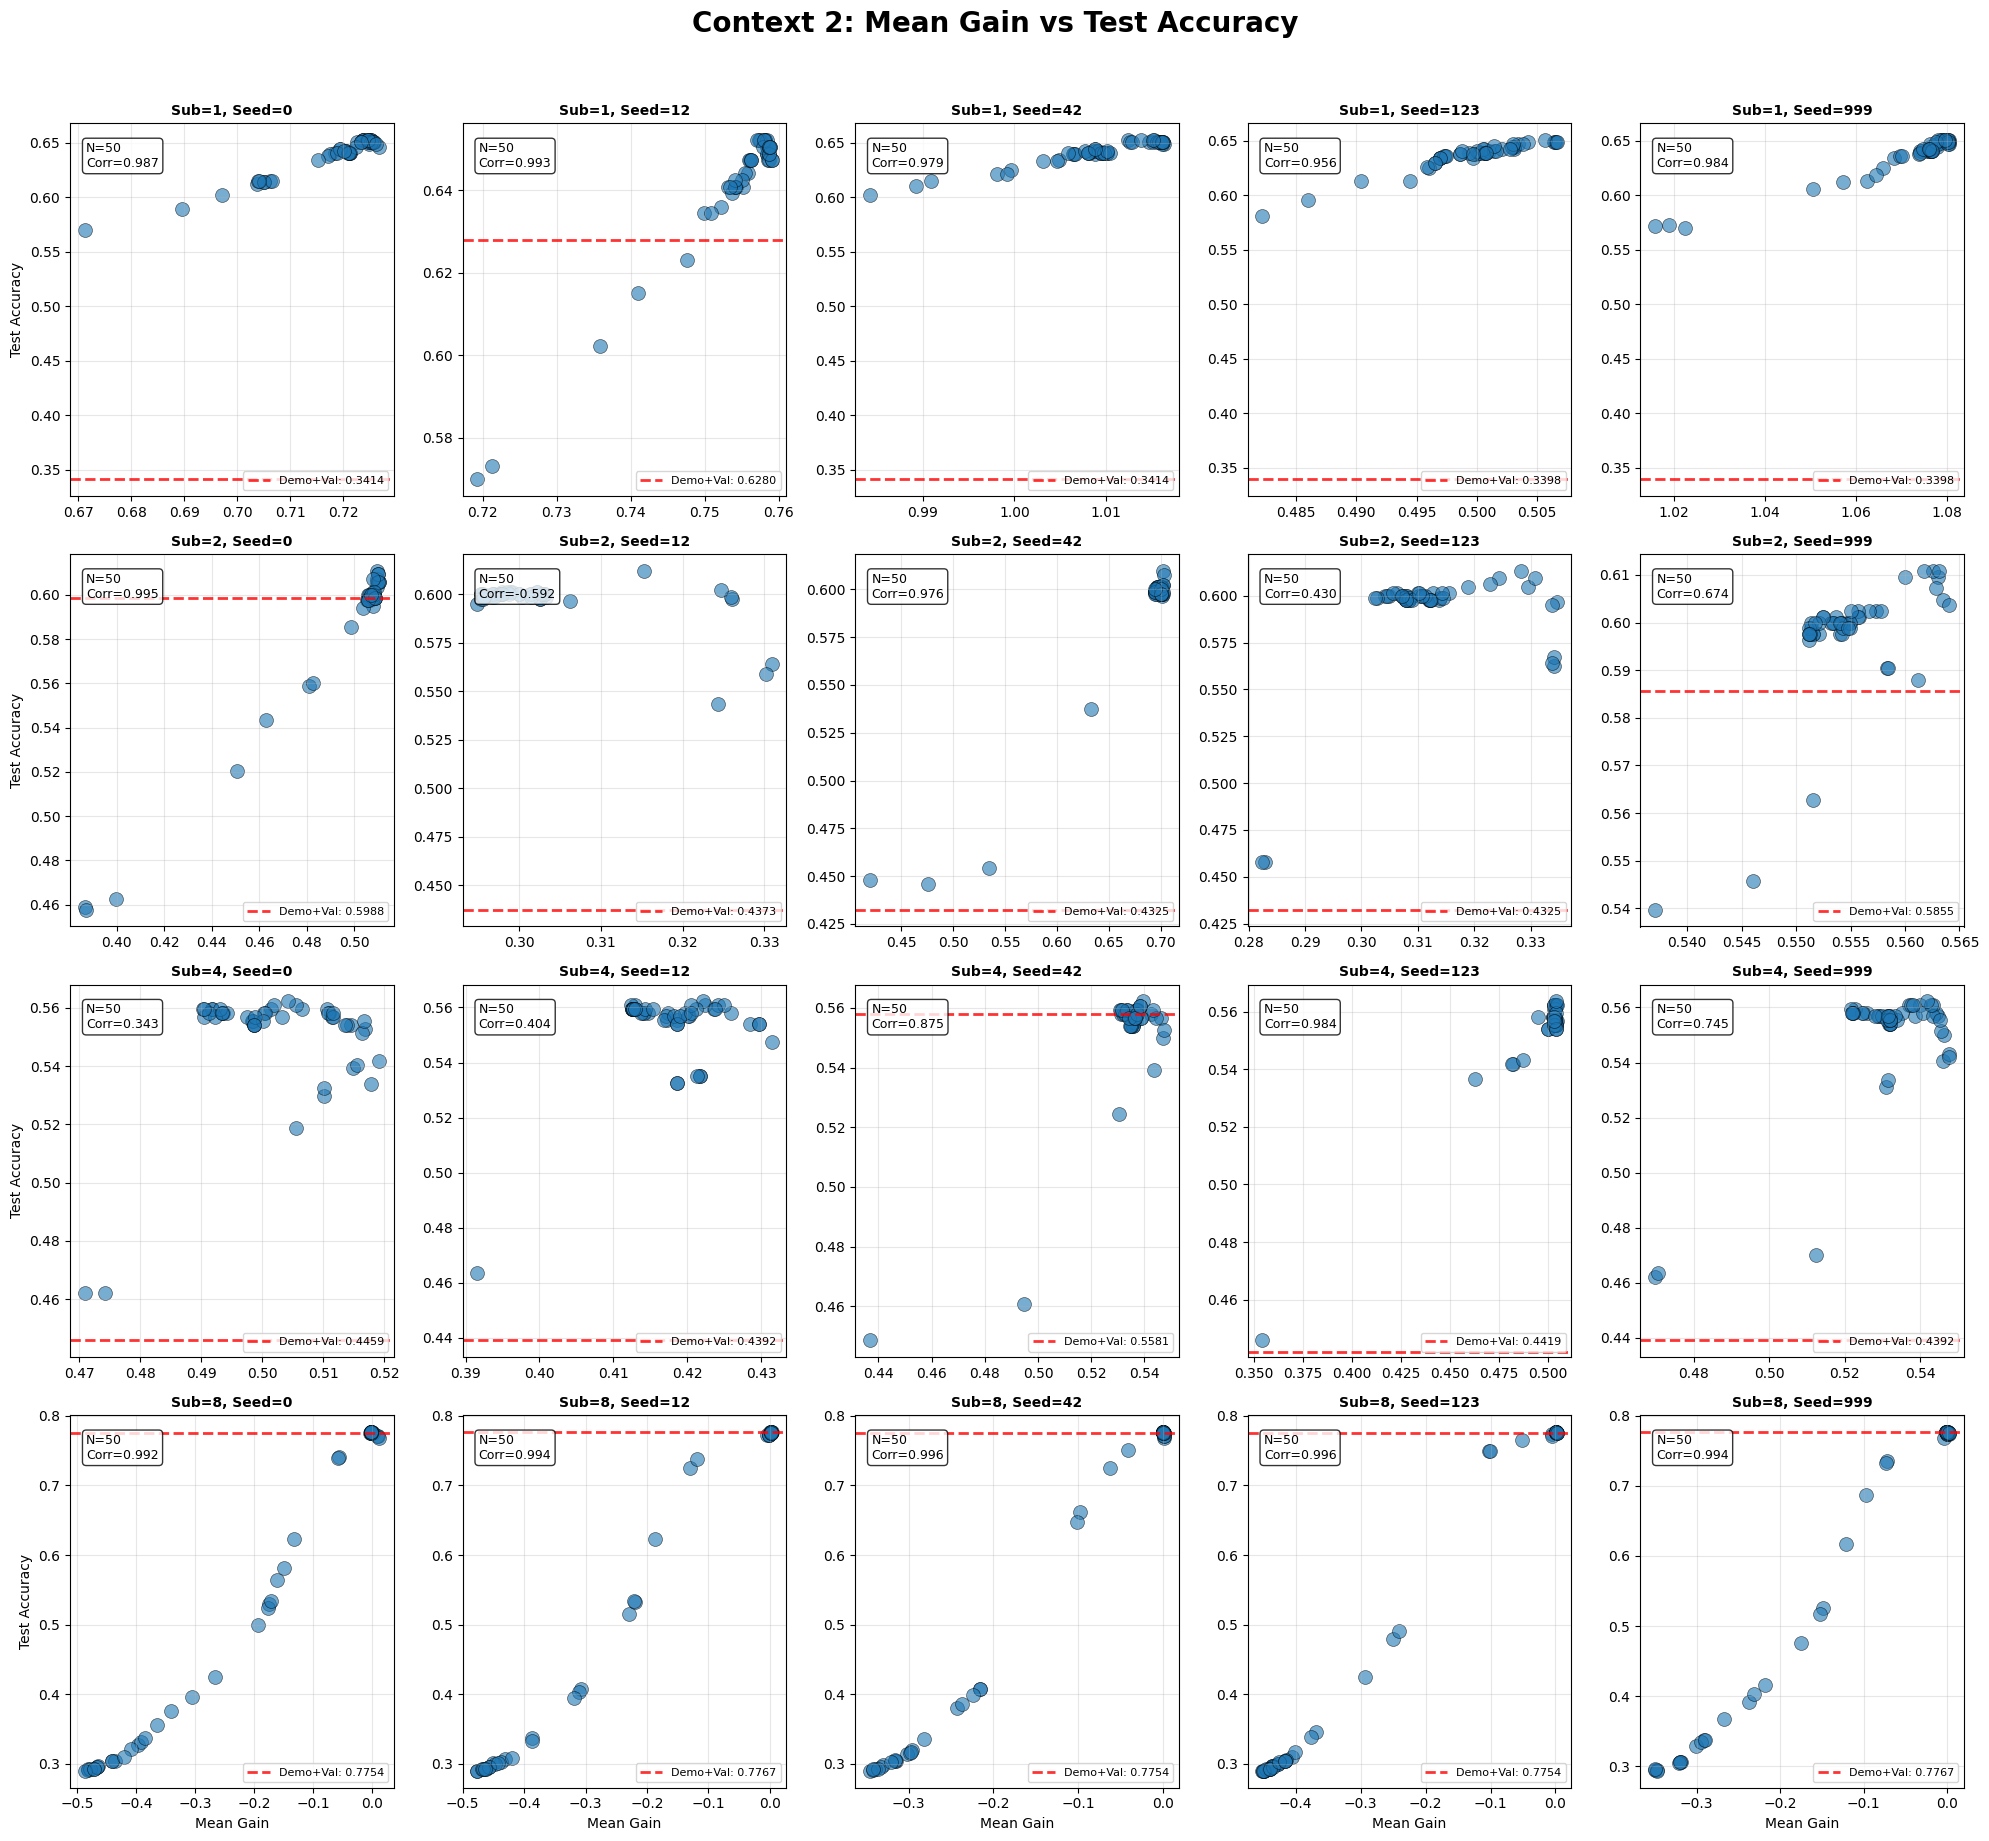

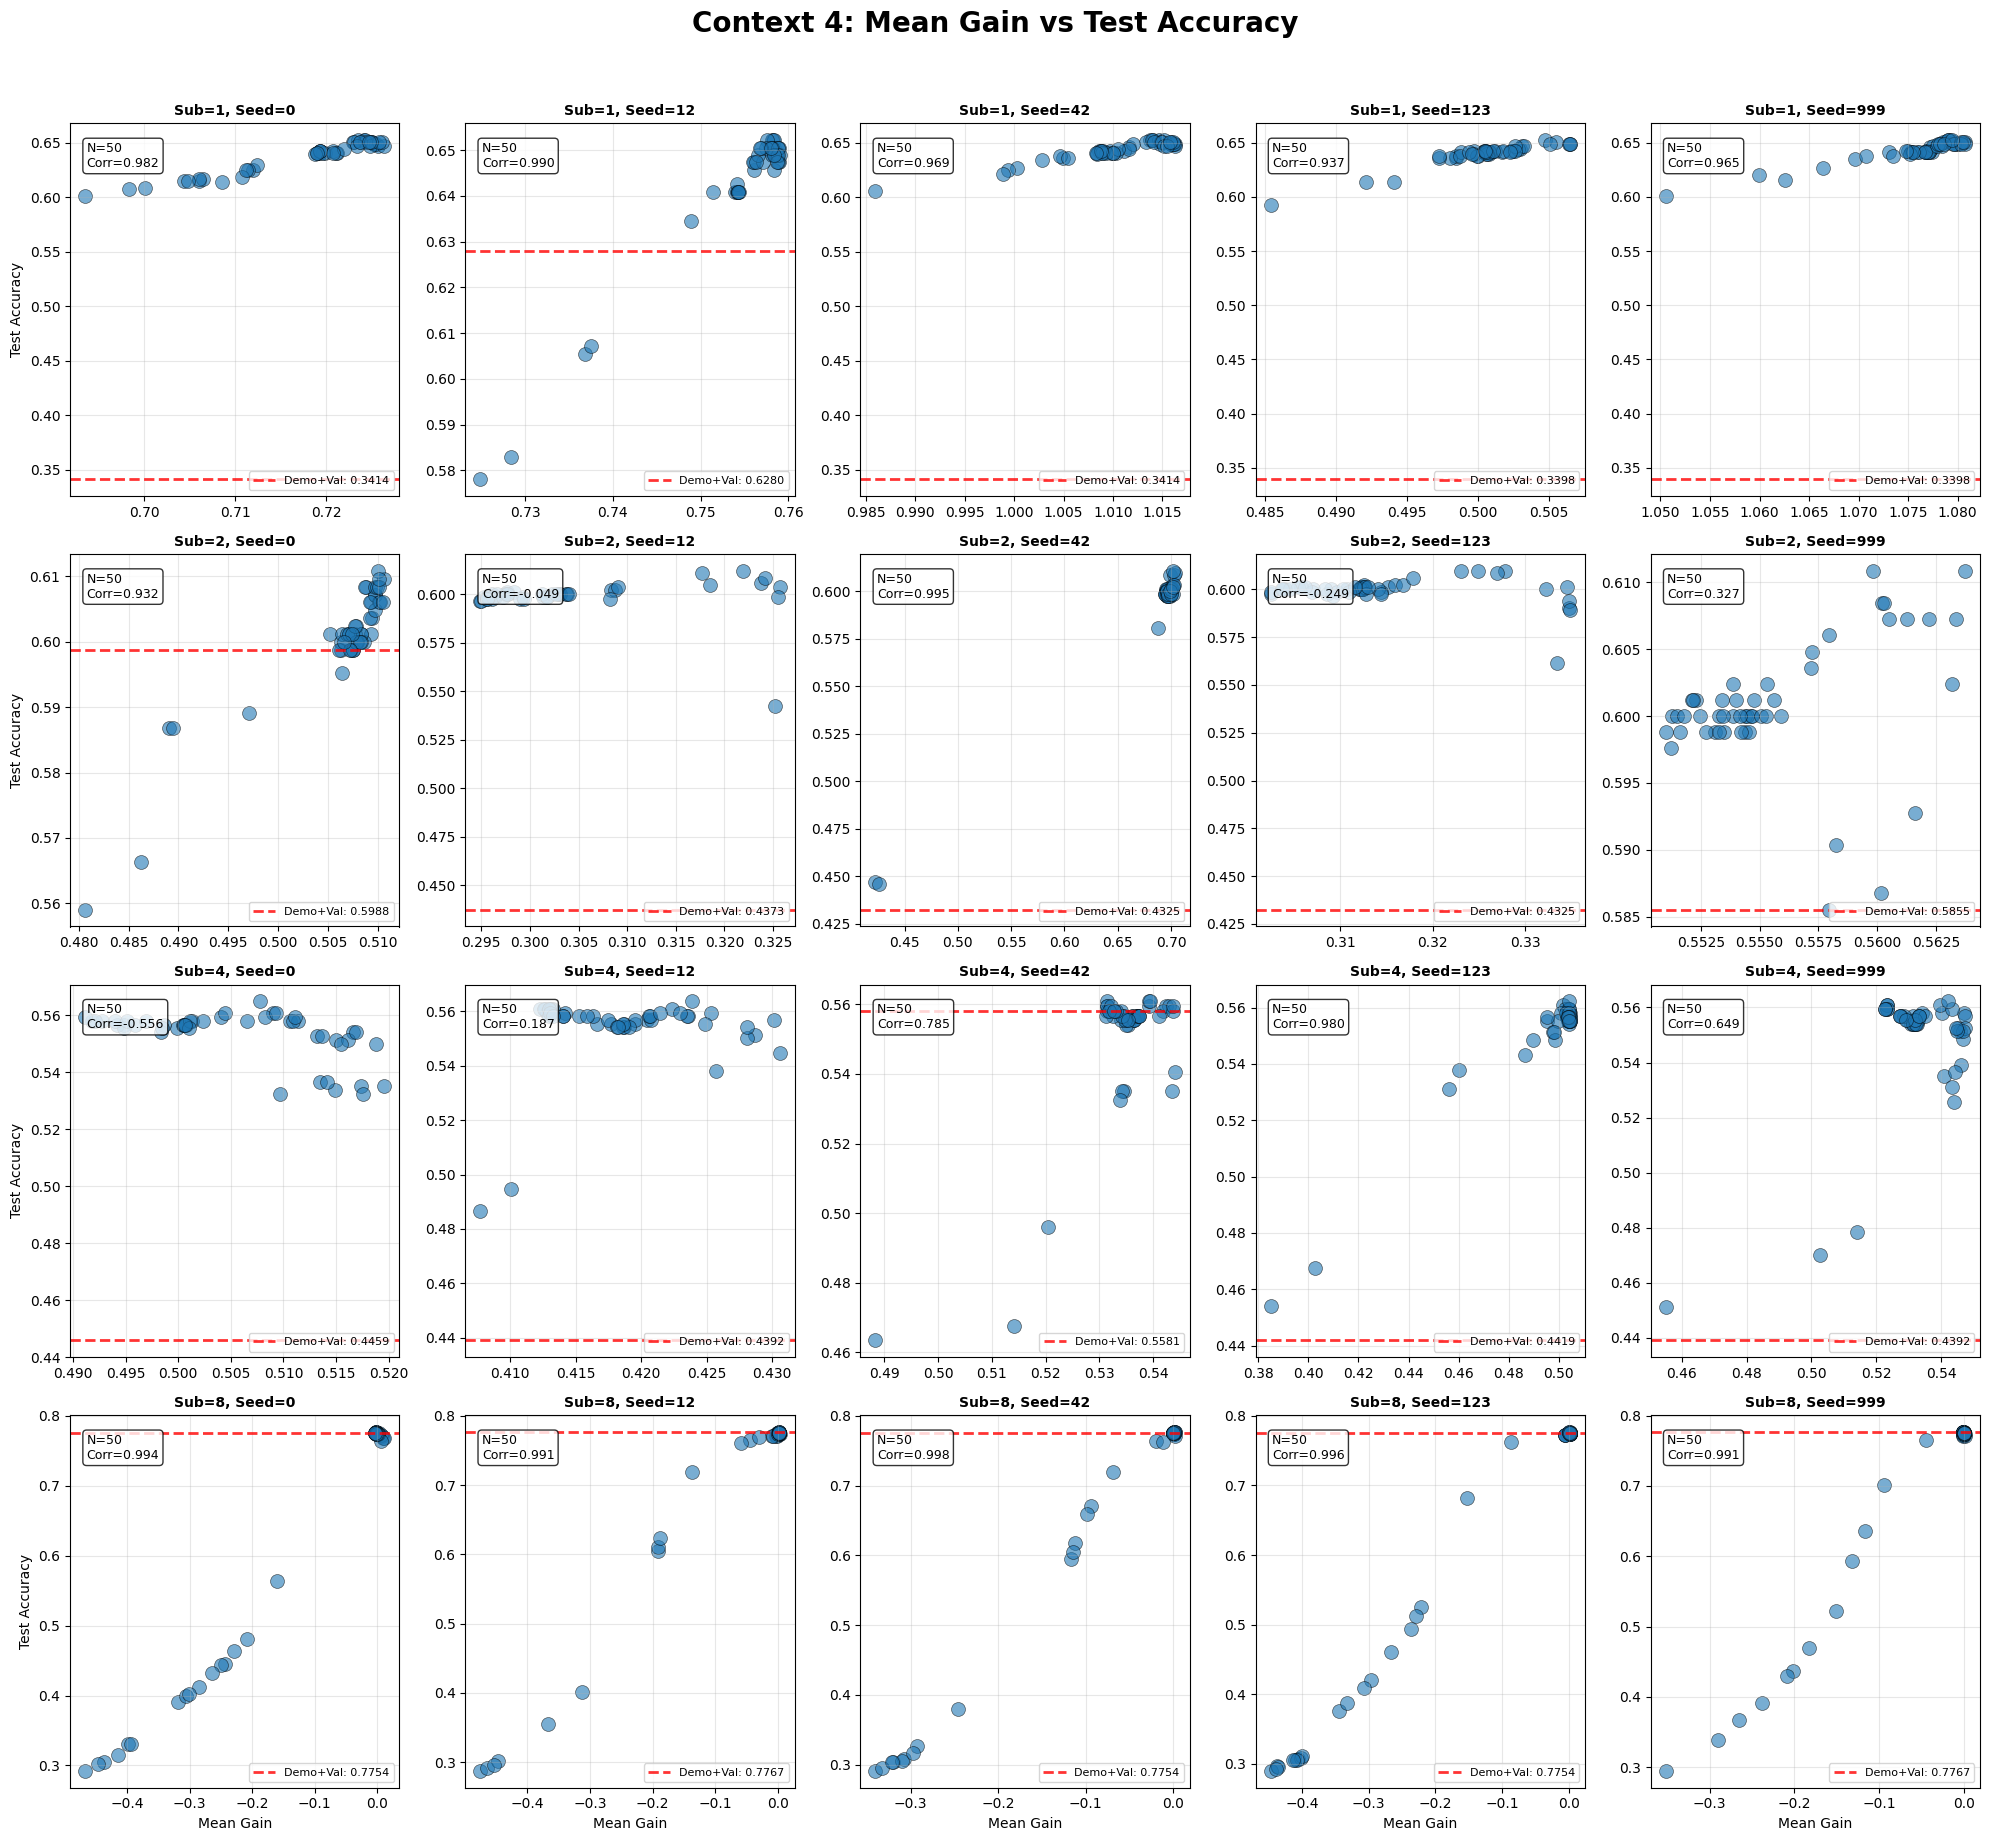

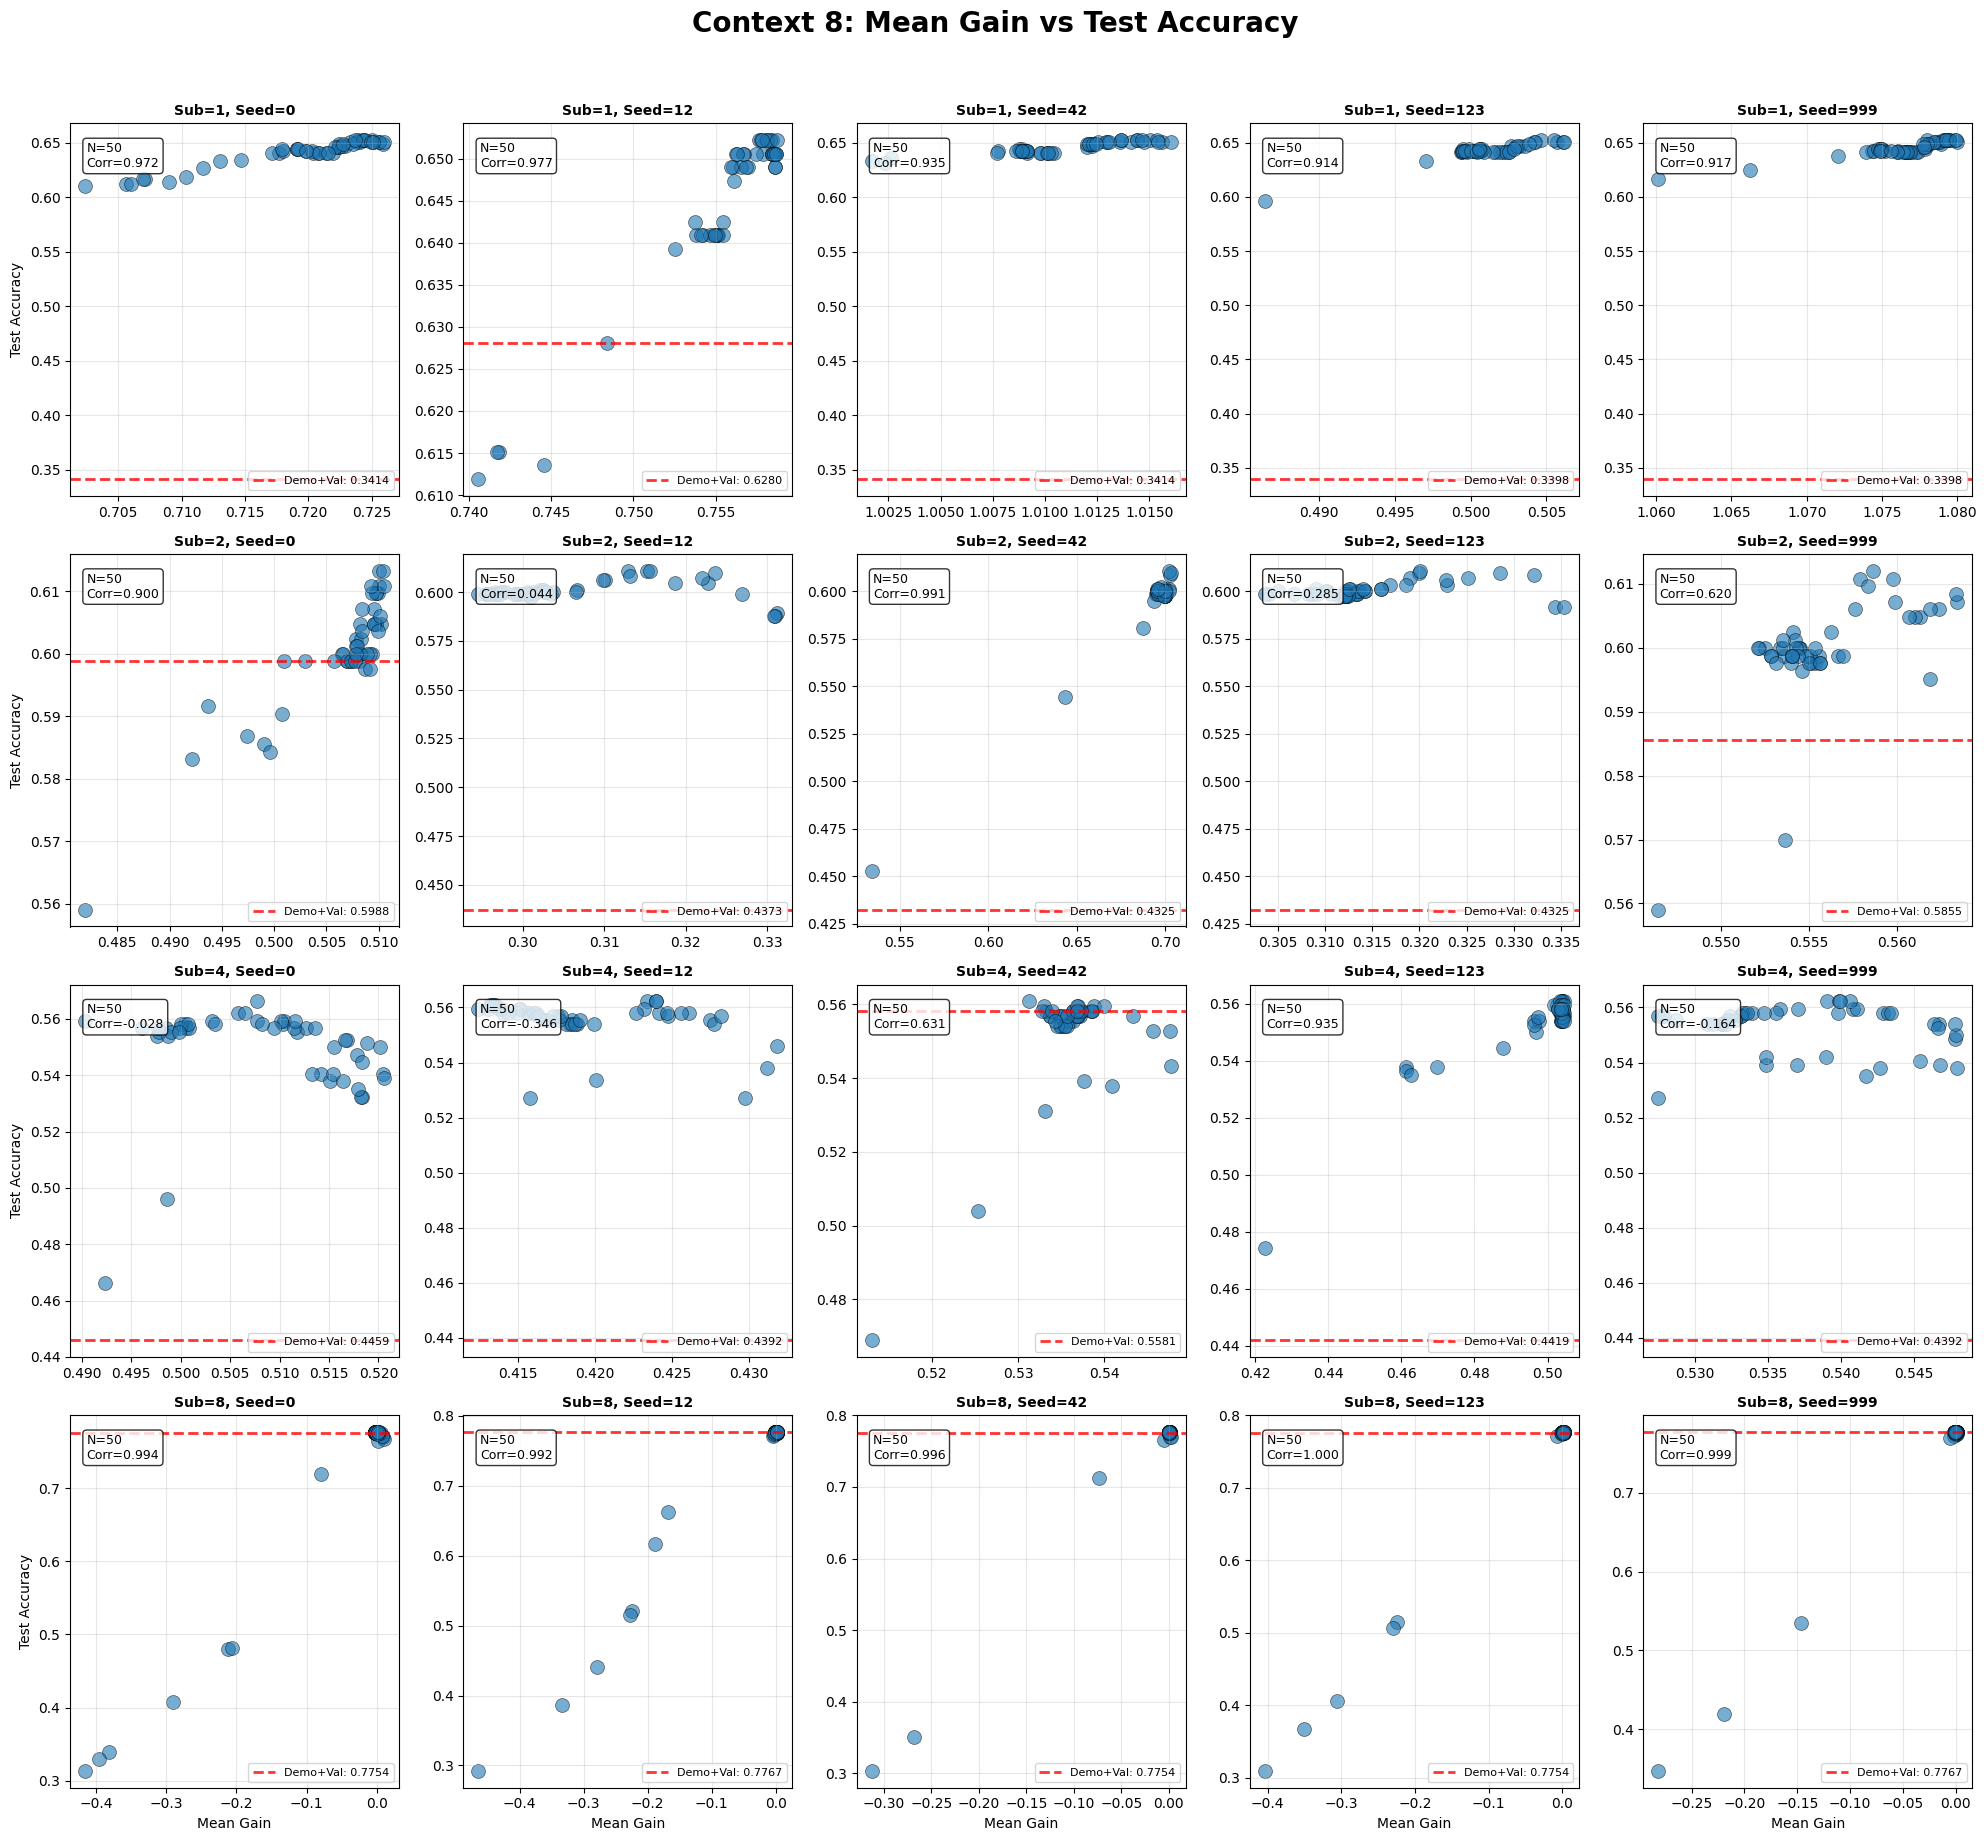

In [6]:
import matplotlib.pyplot as plt

# Get unique contexts from the merged dataframe
unique_contexts = sorted(df_with_gains['context'].unique())

for context_val in unique_contexts:
    # Filter data for the current context
    df_context = df_with_gains[df_with_gains['context'] == context_val]
    
    subsets_sorted = sorted(df_context['subset'].unique())
    seeds_sorted = sorted(df_context['seed'].unique())
    
    # Create a grid of subplots (Subsets x Seeds)
    fig, axes = plt.subplots(len(subsets_sorted), len(seeds_sorted), 
                             figsize=(20, 18), squeeze=False)
    
    for row, subset in enumerate(subsets_sorted):
        for col, seed in enumerate(seeds_sorted):
            ax = axes[row, col]
            
            # Filter data and drop NaNs for correlation calculation
            data = df_context[(df_context['subset'] == subset) & (df_context['seed'] == seed)]
            data = data.dropna(subset=['mean_gain', 'test_accuracy'])
            
            if not data.empty:
                ax.scatter(data['mean_gain'], data['test_accuracy'],
                          alpha=0.6, s=100, edgecolors='black', linewidth=0.5, color='tab:blue')
                
                # Calculate correlation
                corr = data['mean_gain'].corr(data['test_accuracy'])
                ax.text(0.05, 0.95, f'N={len(data)}\nCorr={corr:.3f}', 
                        transform=ax.transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)
                
                # Add horizontal line for demo+val accuracy
                if (subset, seed) in demo_val_accuracies:
                    demo_val_acc = demo_val_accuracies[(subset, seed)]
                    ax.axhline(y=demo_val_acc, color='red', linestyle='--', linewidth=2, 
                              label=f'Demo+Val: {demo_val_acc:.4f}', alpha=0.8)
                    ax.legend(fontsize=8, loc='lower right')
            
            ax.set_title(f'Sub={subset}, Seed={seed}', fontsize=10, fontweight='bold')
            if row == len(subsets_sorted) - 1: ax.set_xlabel('Mean Gain')
            if col == 0: ax.set_ylabel('Test Accuracy')
            ax.grid(True, alpha=0.3)

    plt.suptitle(f'Context {context_val}: Mean Gain vs Test Accuracy', 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure for this context
    plt.savefig(f'figures/gain_vs_accuracy_context_{context_val}.png', dpi=300, bbox_inches='tight')
    plt.show()